In [1]:
%load_ext autoreload
%autoreload 2

import os
import glob
from pathlib import Path
import sys
import pyarrow
import pandas as pd


PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from src.config.config import DATA_PROCESSED, DATA_FEATURES, MODELS_BASELINE,MODELS_METRICS
from src.repository.parquet_repository import ParquetRepository
from src.models.LightGBMRegressorBaseLine import LightGBMRegressorBaseLine
from src.models.LightGBMRegressorAnomaly import LightGBMRegressorAnomaly



In [2]:
repo = ParquetRepository(DATA_FEATURES)

In [3]:
df_features = repo.load("beverage_sales_feature.parquet")
df_anomalies = repo.load("anomaly_predictions.parquet")

df_features["Order_Date"] = pd.to_datetime(df_features["Order_Date"])
df_anomalies["Order_Date"] = pd.to_datetime(df_anomalies["Order_Date"])

[OK] Arquivo carregado: D:\PROJETOS\git_repo\BEVERAGE-SALES\data\features\beverage_sales_feature.parquet
[OK] Arquivo carregado: D:\PROJETOS\git_repo\BEVERAGE-SALES\data\features\anomaly_predictions.parquet


In [4]:
print (df_anomalies.dtypes)

Order_Date                  datetime64[ns]
Category                            object
Product                             object
Region                              object
quantity_sum                       float64
total_price_sum                    float64
unit_price_mean                    float64
discount_mean                      float64
order_count                        float64
customer_count                     float64
avg_ticket                         float64
day_of_week                          int32
month                                int32
year                                 int32
is_weekend                           int64
quantity_sum_mean_7d               float64
quantity_sum_std_7d                float64
quantity_sum_sum_7d                float64
total_price_sum_mean_7d            float64
total_price_sum_std_7d             float64
total_price_sum_mean_30d           float64
unit_price_mean_mean_7d            float64
discount_mean_mean_14d             float64
quantity_vs

In [5]:
df_model_with_anomaly = df_features.merge(
    df_anomalies,
    on=["Order_Date", "Product", "Region"],
    how="left"
)

In [7]:
print (df_anomalies.dtypes)

Order_Date                  datetime64[ns]
Category                            object
Product                             object
Region                              object
quantity_sum                       float64
total_price_sum                    float64
unit_price_mean                    float64
discount_mean                      float64
order_count                        float64
customer_count                     float64
avg_ticket                         float64
day_of_week                          int32
month                                int32
year                                 int32
is_weekend                           int64
quantity_sum_mean_7d               float64
quantity_sum_std_7d                float64
quantity_sum_sum_7d                float64
total_price_sum_mean_7d            float64
total_price_sum_std_7d             float64
total_price_sum_mean_30d           float64
unit_price_mean_mean_7d            float64
discount_mean_mean_14d             float64
quantity_vs

In [11]:
df_anomalies["Order_Date"] = pd.to_datetime(df_anomalies["Order_Date"])

df_train_anomaly = df_anomalies[df_anomalies["Order_Date"].dt.year.isin([2021, 2022])].copy()
df_test_anomaly = df_anomalies[df_anomalies["Order_Date"].dt.year == 2023].copy()

In [12]:
print (df_test_anomaly.dtypes)

Order_Date                  datetime64[ns]
Category                            object
Product                             object
Region                              object
quantity_sum                       float64
total_price_sum                    float64
unit_price_mean                    float64
discount_mean                      float64
order_count                        float64
customer_count                     float64
avg_ticket                         float64
day_of_week                          int32
month                                int32
year                                 int32
is_weekend                           int64
quantity_sum_mean_7d               float64
quantity_sum_std_7d                float64
quantity_sum_sum_7d                float64
total_price_sum_mean_7d            float64
total_price_sum_std_7d             float64
total_price_sum_mean_30d           float64
unit_price_mean_mean_7d            float64
discount_mean_mean_14d             float64
quantity_vs

In [13]:
target_col = "quantity_sum"

numeric_features = [
    "total_price_sum",
    "unit_price_mean",
    "discount_mean",
    "order_count",
    "customer_count",
    "avg_ticket",
    "day_of_week",
    "month",
    "is_weekend",
    "quantity_sum_mean_7d",
    "quantity_sum_std_7d",
    "quantity_sum_sum_7d",
    "total_price_sum_mean_7d",
    "total_price_sum_std_7d",
    "total_price_sum_mean_30d",
    "unit_price_mean_mean_7d",
    "discount_mean_mean_14d",
    "quantity_vs_mean_7d",
    "total_price_vs_mean_30d",
    "quantity_pct_vs_mean_7d",
    "history_less_than_7d",
    "history_less_than_30d",
    "anomaly_score",
    "anomaly_flag"
]

categorical_features = [
    "Product",
    "Region"
]

anomaly_model = LightGBMRegressorAnomaly(
    target_col=target_col,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    model_dir=MODELS_BASELINE,
    random_state=3,
    n_splits=3,
    scoring="neg_root_mean_squared_error"
)

grid_result = anomaly_model.fit(df_anomalies)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


In [14]:
metrics = anomaly_model.evaluate(df_anomalies)

print(metrics)

d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'mae': 2.698217109429507, 'rmse': np.float64(4.106614811293093), 'r2': 0.9993228776253019}


In [15]:
model_path = anomaly_model.save_model(filename="lightgbm_anomalies_model.joblib")
params_path = anomaly_model.save_best_params(filename="lightgbm_anomalies_metrics.json")
#metrics_path = baseline_model.save_metrics(MODELS_METRICS)

print("Model saved at:", model_path)
print("Best params saved at:", params_path)
#print("Metrics saved at:", metrics_path)

Model saved at: D:\PROJETOS\git_repo\BEVERAGE-SALES\models\baseline\lightgbm_anomalies_model.joblib
Best params saved at: D:\PROJETOS\git_repo\BEVERAGE-SALES\models\baseline\lightgbm_anomalies_metrics.json


In [16]:
df_eval = df_anomalies.copy()

df_eval["y_true"] = df_eval["quantity_sum"]
df_eval["y_pred"] = anomaly_model.predict(df_eval)
df_eval["abs_error"] = abs(df_eval["y_true"] - df_eval["y_pred"])

df_eval.groupby("anomaly_flag")["abs_error"].agg(
    count="count",
    mean_abs_error="mean",
    median_abs_error="median",
    max_abs_error="max"
)

d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,count,mean_abs_error,median_abs_error,max_abs_error
anomaly_flag,,,,
0,814460,2.671744,1.894617,178.650378
1,8227,5.318977,2.265651,114.566744


In [37]:
import pandas as pd
import numpy as np


def compare_models_by_anomaly_flag(
    df_baseline: pd.DataFrame,
    df_with_anomaly: pd.DataFrame,
    baseline_model,
    anomaly_model,
    target_col: str = "quantity_sum",
    anomaly_flag_col: str = "anomaly_flag",
    id_columns: list = None
):
    df_base = df_baseline.copy().reset_index(drop=True)
    df_anom = df_with_anomaly.copy().reset_index(drop=True)

    if target_col not in df_base.columns:
        raise ValueError(f"'{target_col}' not found in df_baseline")

    if target_col not in df_anom.columns:
        raise ValueError(f"'{target_col}' not found in df_with_anomaly")

    if anomaly_flag_col not in df_anom.columns:
        raise ValueError(f"'{anomaly_flag_col}' not found in df_with_anomaly")

    if id_columns is not None:
        required_base = set(id_columns + [target_col])
        required_anom = set(id_columns + [target_col, anomaly_flag_col])

        missing_base = [c for c in required_base if c not in df_base.columns]
        missing_anom = [c for c in required_anom if c not in df_anom.columns]

        if missing_base:
            raise ValueError(f"Missing columns in df_baseline: {missing_base}")

        if missing_anom:
            raise ValueError(f"Missing columns in df_with_anomaly: {missing_anom}")

        df_compare = df_anom[id_columns + [target_col, anomaly_flag_col]].merge(
            df_base[id_columns],
            on=id_columns,
            how="inner"
        )

        if df_compare.empty:
            raise ValueError("No matching rows found between df_baseline and df_with_anomaly using id_columns.")

        matched_base = df_base.merge(df_compare[id_columns], on=id_columns, how="inner")
        matched_anom = df_anom.merge(df_compare[id_columns], on=id_columns, how="inner")

        baseline_pred = baseline_model.predict(matched_base)
        anomaly_pred = anomaly_model.predict(matched_anom)

        df_compare = matched_anom[id_columns + [target_col, anomaly_flag_col]].copy()
        df_compare["baseline_pred"] = baseline_pred
        df_compare["anomaly_pred"] = anomaly_pred

    else:
        if len(df_base) != len(df_anom):
            raise ValueError("DataFrames have different lengths. Provide id_columns to align them safely.")

        df_compare = pd.DataFrame({
            target_col: df_anom[target_col].values,
            anomaly_flag_col: df_anom[anomaly_flag_col].values
        })

        df_compare["baseline_pred"] = baseline_model.predict(df_base)
        df_compare["anomaly_pred"] = anomaly_model.predict(df_anom)

    df_compare["baseline_abs_error"] = np.abs(df_compare[target_col] - df_compare["baseline_pred"])
    df_compare["anomaly_abs_error"] = np.abs(df_compare[target_col] - df_compare["anomaly_pred"])

    df_compare["baseline_sq_error"] = (df_compare[target_col] - df_compare["baseline_pred"]) ** 2
    df_compare["anomaly_sq_error"] = (df_compare[target_col] - df_compare["anomaly_pred"]) ** 2

    report = df_compare.groupby(anomaly_flag_col).agg(
        count=(target_col, "count"),
        baseline_mae=("baseline_abs_error", "mean"),
        anomaly_model_mae=("anomaly_abs_error", "mean"),
        baseline_median_ae=("baseline_abs_error", "median"),
        anomaly_model_median_ae=("anomaly_abs_error", "median"),
        baseline_rmse=("baseline_sq_error", lambda x: np.sqrt(np.mean(x))),
        anomaly_model_rmse=("anomaly_sq_error", lambda x: np.sqrt(np.mean(x))),
        baseline_max_ae=("baseline_abs_error", "max"),
        anomaly_model_max_ae=("anomaly_abs_error", "max")
    ).reset_index()

    report["mae_improvement"] = report["baseline_mae"] - report["anomaly_model_mae"]
    report["rmse_improvement"] = report["baseline_rmse"] - report["anomaly_model_rmse"]

    report["mae_improvement_pct"] = np.where(
        report["baseline_mae"] != 0,
        (report["mae_improvement"] / report["baseline_mae"]) * 100,
        0.0
    )

    report["rmse_improvement_pct"] = np.where(
        report["baseline_rmse"] != 0,
        (report["rmse_improvement"] / report["baseline_rmse"]) * 100,
        0.0
    )

    return report, df_compare

In [39]:
target_col = "quantity_sum"

numeric_features = [
    "total_price_sum",
    "unit_price_mean",
    "discount_mean",
    "order_count",
    "customer_count",
    "avg_ticket",
    "day_of_week",
    "month",
    "is_weekend",
    "quantity_sum_mean_7d",
    "quantity_sum_std_7d",
    "quantity_sum_sum_7d",
    "total_price_sum_mean_7d",
    "total_price_sum_std_7d",
    "total_price_sum_mean_30d",
    "unit_price_mean_mean_7d",
    "discount_mean_mean_14d",
    "quantity_vs_mean_7d",
    "total_price_vs_mean_30d",
    "quantity_pct_vs_mean_7d",
    "history_less_than_7d",
    "history_less_than_30d"
]

categorical_features = [
    "Product",
    "Region"
]

baseline_model = LightGBMRegressorBaseLine(
    target_col=target_col,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    model_dir=MODELS_BASELINE,
    random_state=3,
    n_splits=3,
    scoring="neg_root_mean_squared_error"
)

BOSAT = r"D:\PROJETOS\git_repo\BEVERAGE-SALES\models\baseline\lightgbm_baseline_model.joblib"
baseline_model.load_model(BOSAT)

In [26]:
target_col = "quantity_sum"

numeric_features = [
    "total_price_sum",
    "unit_price_mean",
    "discount_mean",
    "order_count",
    "customer_count",
    "avg_ticket",
    "day_of_week",
    "month",
    "is_weekend",
    "quantity_sum_mean_7d",
    "quantity_sum_std_7d",
    "quantity_sum_sum_7d",
    "total_price_sum_mean_7d",
    "total_price_sum_std_7d",
    "total_price_sum_mean_30d",
    "unit_price_mean_mean_7d",
    "discount_mean_mean_14d",
    "quantity_vs_mean_7d",
    "total_price_vs_mean_30d",
    "quantity_pct_vs_mean_7d",
    "history_less_than_7d",
    "history_less_than_30d",
    "anomaly_score",
    "anomaly_flag"
]

categorical_features = [
    "Product",
    "Region"
]

anomaly_model = LightGBMRegressorAnomaly(
    target_col=target_col,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    model_dir=MODELS_BASELINE,
    random_state=3,
    n_splits=3,
    scoring="neg_root_mean_squared_error"
)

BOSAT = r"D:\PROJETOS\git_repo\BEVERAGE-SALES\models\baseline\lightgbm_anomalies_model.joblib"
anomaly_model.load_model(BOSAT)

In [33]:
df_features["Order_Date"] = pd.to_datetime(df_features["Order_Date"])

df_train_features = df_features[df_features["Order_Date"].dt.year.isin([2021, 2022])].copy()
df_test_features = df_features[df_features["Order_Date"].dt.year == 2023].copy()

In [34]:
df_anomalies["Order_Date"] = pd.to_datetime(df_anomalies["Order_Date"])

df_train_anomalies = df_anomalies[df_anomalies["Order_Date"].dt.year.isin([2021, 2022])].copy()
df_test_anomalies = df_anomalies[df_anomalies["Order_Date"].dt.year == 2023].copy()

In [29]:
print(df_test_features.dtypes)

Order_Date                  datetime64[ns]
Category                            object
Product                             object
Region                              object
quantity_sum                       float64
total_price_sum                    float64
unit_price_mean                    float64
discount_mean                      float64
order_count                        float64
customer_count                     float64
avg_ticket                         float64
day_of_week                          int32
month                                int32
year                                 int32
is_weekend                           int64
quantity_sum_mean_7d               float64
quantity_sum_std_7d                float64
quantity_sum_sum_7d                float64
total_price_sum_mean_7d            float64
total_price_sum_std_7d             float64
total_price_sum_mean_30d           float64
unit_price_mean_mean_7d            float64
discount_mean_mean_14d             float64
quantity_vs

In [30]:
print (df_test_anomaly.dtypes)

Order_Date                  datetime64[ns]
Category                            object
Product                             object
Region                              object
quantity_sum                       float64
total_price_sum                    float64
unit_price_mean                    float64
discount_mean                      float64
order_count                        float64
customer_count                     float64
avg_ticket                         float64
day_of_week                          int32
month                                int32
year                                 int32
is_weekend                           int64
quantity_sum_mean_7d               float64
quantity_sum_std_7d                float64
quantity_sum_sum_7d                float64
total_price_sum_mean_7d            float64
total_price_sum_std_7d             float64
total_price_sum_mean_30d           float64
unit_price_mean_mean_7d            float64
discount_mean_mean_14d             float64
quantity_vs

In [40]:
report, df_compare = compare_models_by_anomaly_flag(
    df_baseline=df_test_features,
    df_with_anomaly=df_test_anomaly,
    baseline_model=baseline_model,
    anomaly_model=anomaly_model,
    target_col="quantity_sum",
    anomaly_flag_col="anomaly_flag",
    id_columns=["Order_Date", "Product", "Region"]
)

d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [41]:
print(report)

   anomaly_flag   count  baseline_mae  anomaly_model_mae  baseline_median_ae  \
0             0  271071      2.777472           2.660743            1.938180   
1             1    2656      3.174978           3.078371            2.096747   

   anomaly_model_median_ae  baseline_rmse  anomaly_model_rmse  \
0                 1.891841       4.317620            3.949275   
1                 1.939884       5.717656            5.322033   

   baseline_max_ae  anomaly_model_max_ae  mae_improvement  rmse_improvement  \
0       263.094056            178.650378         0.116730          0.368345   
1        80.584547             67.309442         0.096607          0.395622   

   mae_improvement_pct  rmse_improvement_pct  
0             4.202728              8.531211  
1             3.042777              6.919310  


In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_model_comparison(
    report: pd.DataFrame,
    metric: str = "mae",
    title: str = None,
    figsize=(10, 6)
):
    """
    Plot a clean comparison chart between the baseline model and the anomaly-aware model.

    Parameters
    ----------
    report : pd.DataFrame
        DataFrame generated by compare_models_by_anomaly_flag().
        Expected columns:
        - anomaly_flag
        - baseline_mae / anomaly_model_mae
        - baseline_rmse / anomaly_model_rmse

    metric : str, default="mae"
        Metric to plot. Accepted values: "mae" or "rmse".

    title : str, optional
        Custom chart title.

    figsize : tuple, default=(10, 6)
        Figure size.
    """
    if metric not in ["mae", "rmse"]:
        raise ValueError("metric must be 'mae' or 'rmse'")

    baseline_col = f"baseline_{metric}"
    anomaly_col = f"anomaly_model_{metric}"

    if baseline_col not in report.columns or anomaly_col not in report.columns:
        raise ValueError(f"Columns {baseline_col} and/or {anomaly_col} not found in report")

    plot_df = report.copy()

    # Label for anomaly flag
    plot_df["group_label"] = plot_df["anomaly_flag"].map({
        0: "Normal",
        1: "Anomalous"
    }).fillna(plot_df["anomaly_flag"].astype(str))

    x = np.arange(len(plot_df))
    width = 0.34

    fig, ax = plt.subplots(figsize=figsize)

    # Pastel colors
    baseline_color = "#CFE8F7"   # pastel blue
    anomaly_color = "#F7D6E0"    # pastel pink

    bars1 = ax.bar(
        x - width / 2,
        plot_df[baseline_col],
        width,
        label="Baseline",
        edgecolor="gray",
        linewidth=0.8,
        color=baseline_color
    )

    bars2 = ax.bar(
        x + width / 2,
        plot_df[anomaly_col],
        width,
        label="With Anomaly Features",
        edgecolor="gray",
        linewidth=0.8,
        color=anomaly_color
    )

    # Labels and title
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["group_label"], fontsize=11)
    ax.set_ylabel(metric.upper(), fontsize=12)

    if title is None:
        title = f"{metric.upper()} Comparison: Baseline vs Anomaly-Aware Model"

    ax.set_title(title, fontsize=14, pad=14)

    # Soft grid
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

    # Clean spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legend
    ax.legend(frameon=False, fontsize=11)

    # Value labels
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(
                f"{height:.3f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=10
            )

    add_labels(bars1)
    add_labels(bars2)

    plt.tight_layout()
    plt.show()

In [43]:
def plot_improvement_percentage(
    report: pd.DataFrame,
    metric: str = "mae",
    figsize=(10, 6)
):
    """
    Plot the percentage improvement of the anomaly-aware model over the baseline.

    Parameters
    ----------
    report : pd.DataFrame
        DataFrame generated by compare_models_by_anomaly_flag().

    metric : str, default="mae"
        Metric to plot. Accepted values: "mae" or "rmse".

    figsize : tuple, default=(10, 6)
        Figure size.
    """
    if metric not in ["mae", "rmse"]:
        raise ValueError("metric must be 'mae' or 'rmse'")

    improvement_col = f"{metric}_improvement_pct"

    if improvement_col not in report.columns:
        raise ValueError(f"Column {improvement_col} not found in report")

    plot_df = report.copy()

    plot_df["group_label"] = plot_df["anomaly_flag"].map({
        0: "Normal",
        1: "Anomalous"
    }).fillna(plot_df["anomaly_flag"].astype(str))

    x = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=figsize)

    improvement_color = "#D9F2D9"  # pastel green

    bars = ax.bar(
        x,
        plot_df[improvement_col],
        width=0.5,
        color=improvement_color,
        edgecolor="gray",
        linewidth=0.8
    )

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["group_label"], fontsize=11)
    ax.set_ylabel("Improvement (%)", fontsize=12)
    ax.set_title(
        f"{metric.upper()} Improvement of Anomaly-Aware Model",
        fontsize=14,
        pad=14
    )

    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.2f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

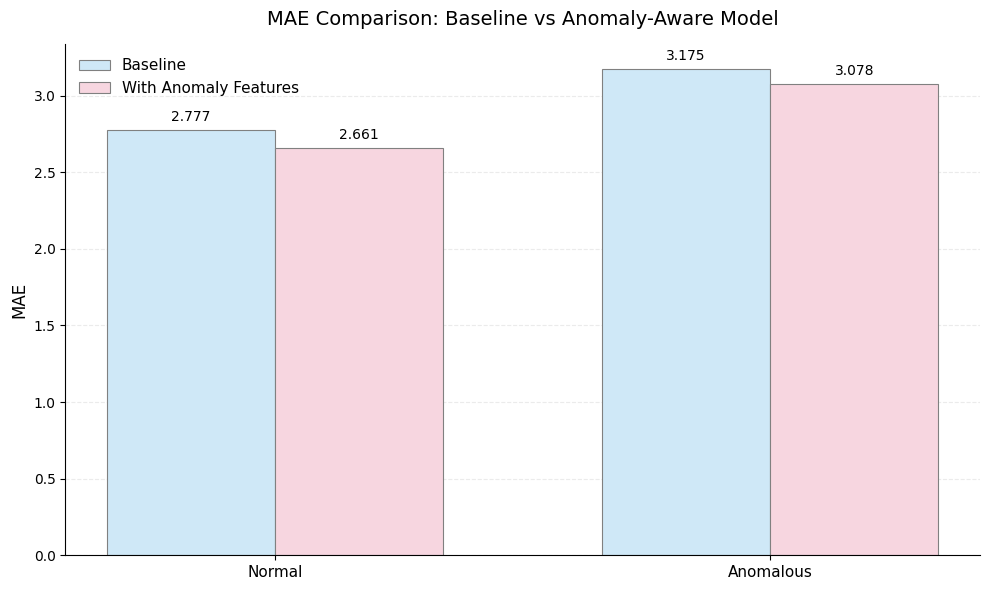

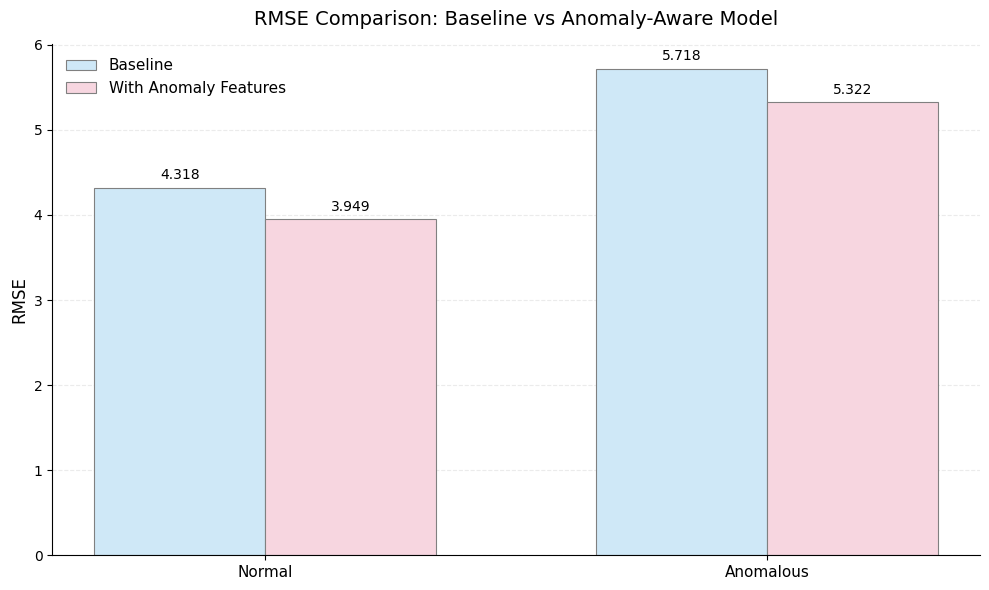

In [44]:
plot_model_comparison(report, metric="mae")
plot_model_comparison(report, metric="rmse")



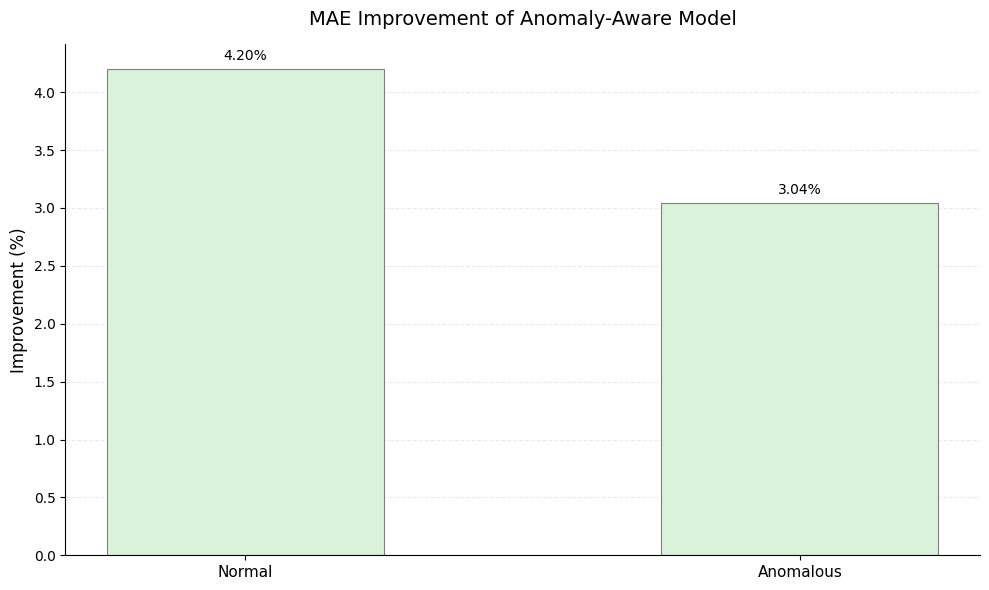

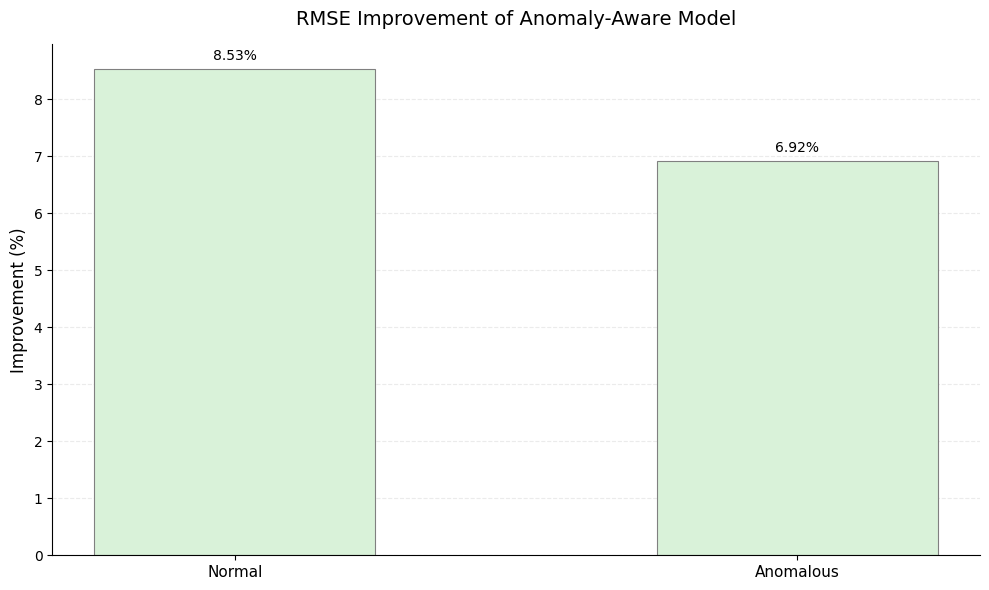

In [45]:
plot_improvement_percentage(report, metric="mae")
plot_improvement_percentage(report, metric="rmse")

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_beautiful_model_comparison(report: pd.DataFrame):
    """
    Plot beautiful comparison charts for baseline vs anomaly-aware model.

    This function creates three clean charts:
    1. MAE comparison
    2. RMSE comparison
    3. Improvement percentage comparison

    Parameters
    ----------
    report : pd.DataFrame
        DataFrame generated by compare_models_by_anomaly_flag().

    Expected columns
    ----------------
    - anomaly_flag
    - baseline_mae
    - anomaly_model_mae
    - baseline_rmse
    - anomaly_model_rmse
    - mae_improvement_pct
    - rmse_improvement_pct
    """
    required_cols = [
        "anomaly_flag",
        "baseline_mae",
        "anomaly_model_mae",
        "baseline_rmse",
        "anomaly_model_rmse",
        "mae_improvement_pct",
        "rmse_improvement_pct"
    ]

    missing_cols = [col for col in required_cols if col not in report.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns in report: {missing_cols}")

    plot_df = report.copy()

    plot_df["group_label"] = plot_df["anomaly_flag"].map({
        0: "Normal",
        1: "Anomalous"
    }).fillna(plot_df["anomaly_flag"].astype(str))

    # Soft pastel palette
    baseline_color = "#CFE8F7"      # pastel blue
    anomaly_color = "#F8D7E3"       # pastel pink
    mae_gain_color = "#DDF3E4"      # pastel green
    rmse_gain_color = "#FBE7C6"     # pastel peach

    # Global style
    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 15,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11
    })

    x = np.arange(len(plot_df))
    width = 0.34

    def _style_axis(ax):
        ax.set_facecolor("#FCFCFC")
        ax.grid(axis="y", linestyle="--", alpha=0.22)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_alpha(0.3)
        ax.spines["bottom"].set_alpha(0.3)

    def _add_bar_labels(ax, bars, fmt="{:.3f}", y_offset=4):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(
                fmt.format(height),
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, y_offset),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=10
            )

    # -----------------------------
    # 1) MAE comparison
    # -----------------------------
    fig, ax = plt.subplots(figsize=(10, 6))

    bars1 = ax.bar(
        x - width / 2,
        plot_df["baseline_mae"],
        width,
        label="Baseline",
        color=baseline_color,
        edgecolor="#9AA4AE",
        linewidth=0.8
    )

    bars2 = ax.bar(
        x + width / 2,
        plot_df["anomaly_model_mae"],
        width,
        label="With Anomaly Features",
        color=anomaly_color,
        edgecolor="#9AA4AE",
        linewidth=0.8
    )

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["group_label"])
    ax.set_ylabel("MAE")
    ax.set_title("MAE by Group — Baseline vs Hybrid Model", pad=14)
    ax.legend(frameon=False)

    _style_axis(ax)
    _add_bar_labels(ax, bars1)
    _add_bar_labels(ax, bars2)

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 2) RMSE comparison
    # -----------------------------
    fig, ax = plt.subplots(figsize=(10, 6))

    bars1 = ax.bar(
        x - width / 2,
        plot_df["baseline_rmse"],
        width,
        label="Baseline",
        color=baseline_color,
        edgecolor="#9AA4AE",
        linewidth=0.8
    )

    bars2 = ax.bar(
        x + width / 2,
        plot_df["anomaly_model_rmse"],
        width,
        label="With Anomaly Features",
        color=anomaly_color,
        edgecolor="#9AA4AE",
        linewidth=0.8
    )

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["group_label"])
    ax.set_ylabel("RMSE")
    ax.set_title("RMSE by Group — Baseline vs Hybrid Model", pad=14)
    ax.legend(frameon=False)

    _style_axis(ax)
    _add_bar_labels(ax, bars1)
    _add_bar_labels(ax, bars2)

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 3) Improvement percentage
    # -----------------------------
    fig, ax = plt.subplots(figsize=(10, 6))

    width2 = 0.34

    bars1 = ax.bar(
        x - width2 / 2,
        plot_df["mae_improvement_pct"],
        width2,
        label="MAE Improvement (%)",
        color=mae_gain_color,
        edgecolor="#9AA4AE",
        linewidth=0.8
    )

    bars2 = ax.bar(
        x + width2 / 2,
        plot_df["rmse_improvement_pct"],
        width2,
        label="RMSE Improvement (%)",
        color=rmse_gain_color,
        edgecolor="#9AA4AE",
        linewidth=0.8
    )

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["group_label"])
    ax.set_ylabel("Improvement (%)")
    ax.set_title("Performance Gain of Hybrid Model", pad=14)
    ax.legend(frameon=False)

    _style_axis(ax)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(
                f"{height:.2f}%",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

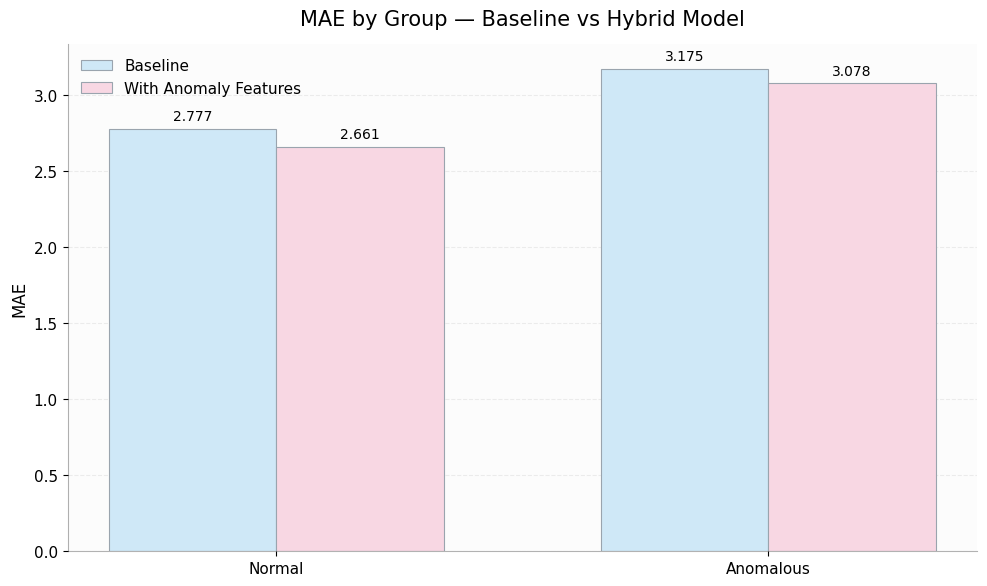

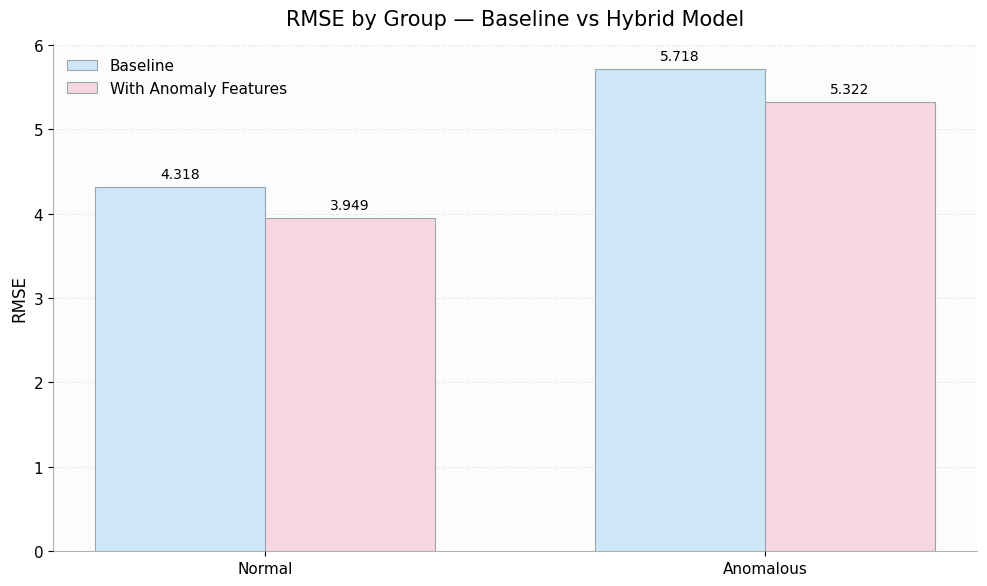

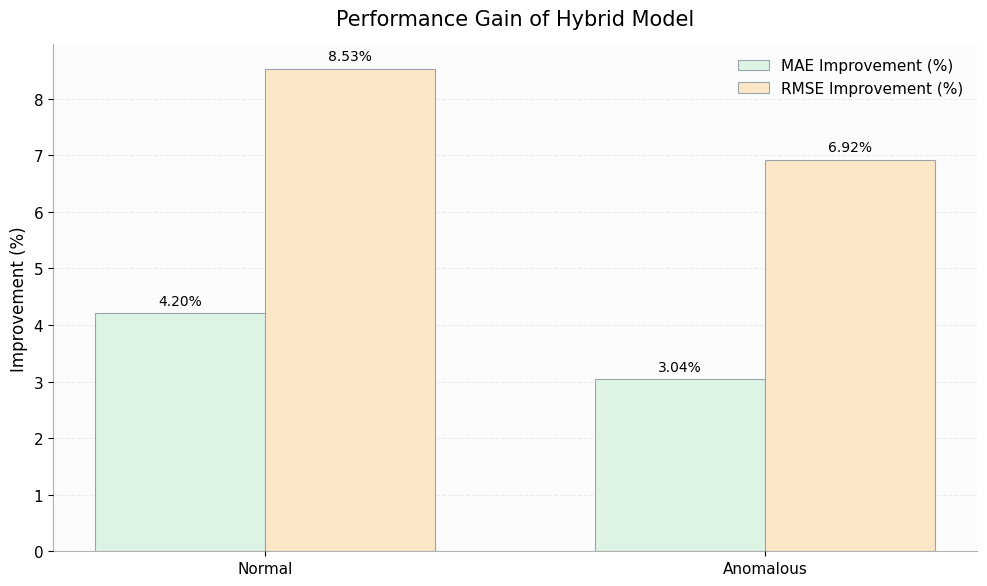

In [47]:
plot_beautiful_model_comparison(report)

C:\Users\AlexK\AppData\Local\Temp\ipykernel_16424\2536587758.py:150: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


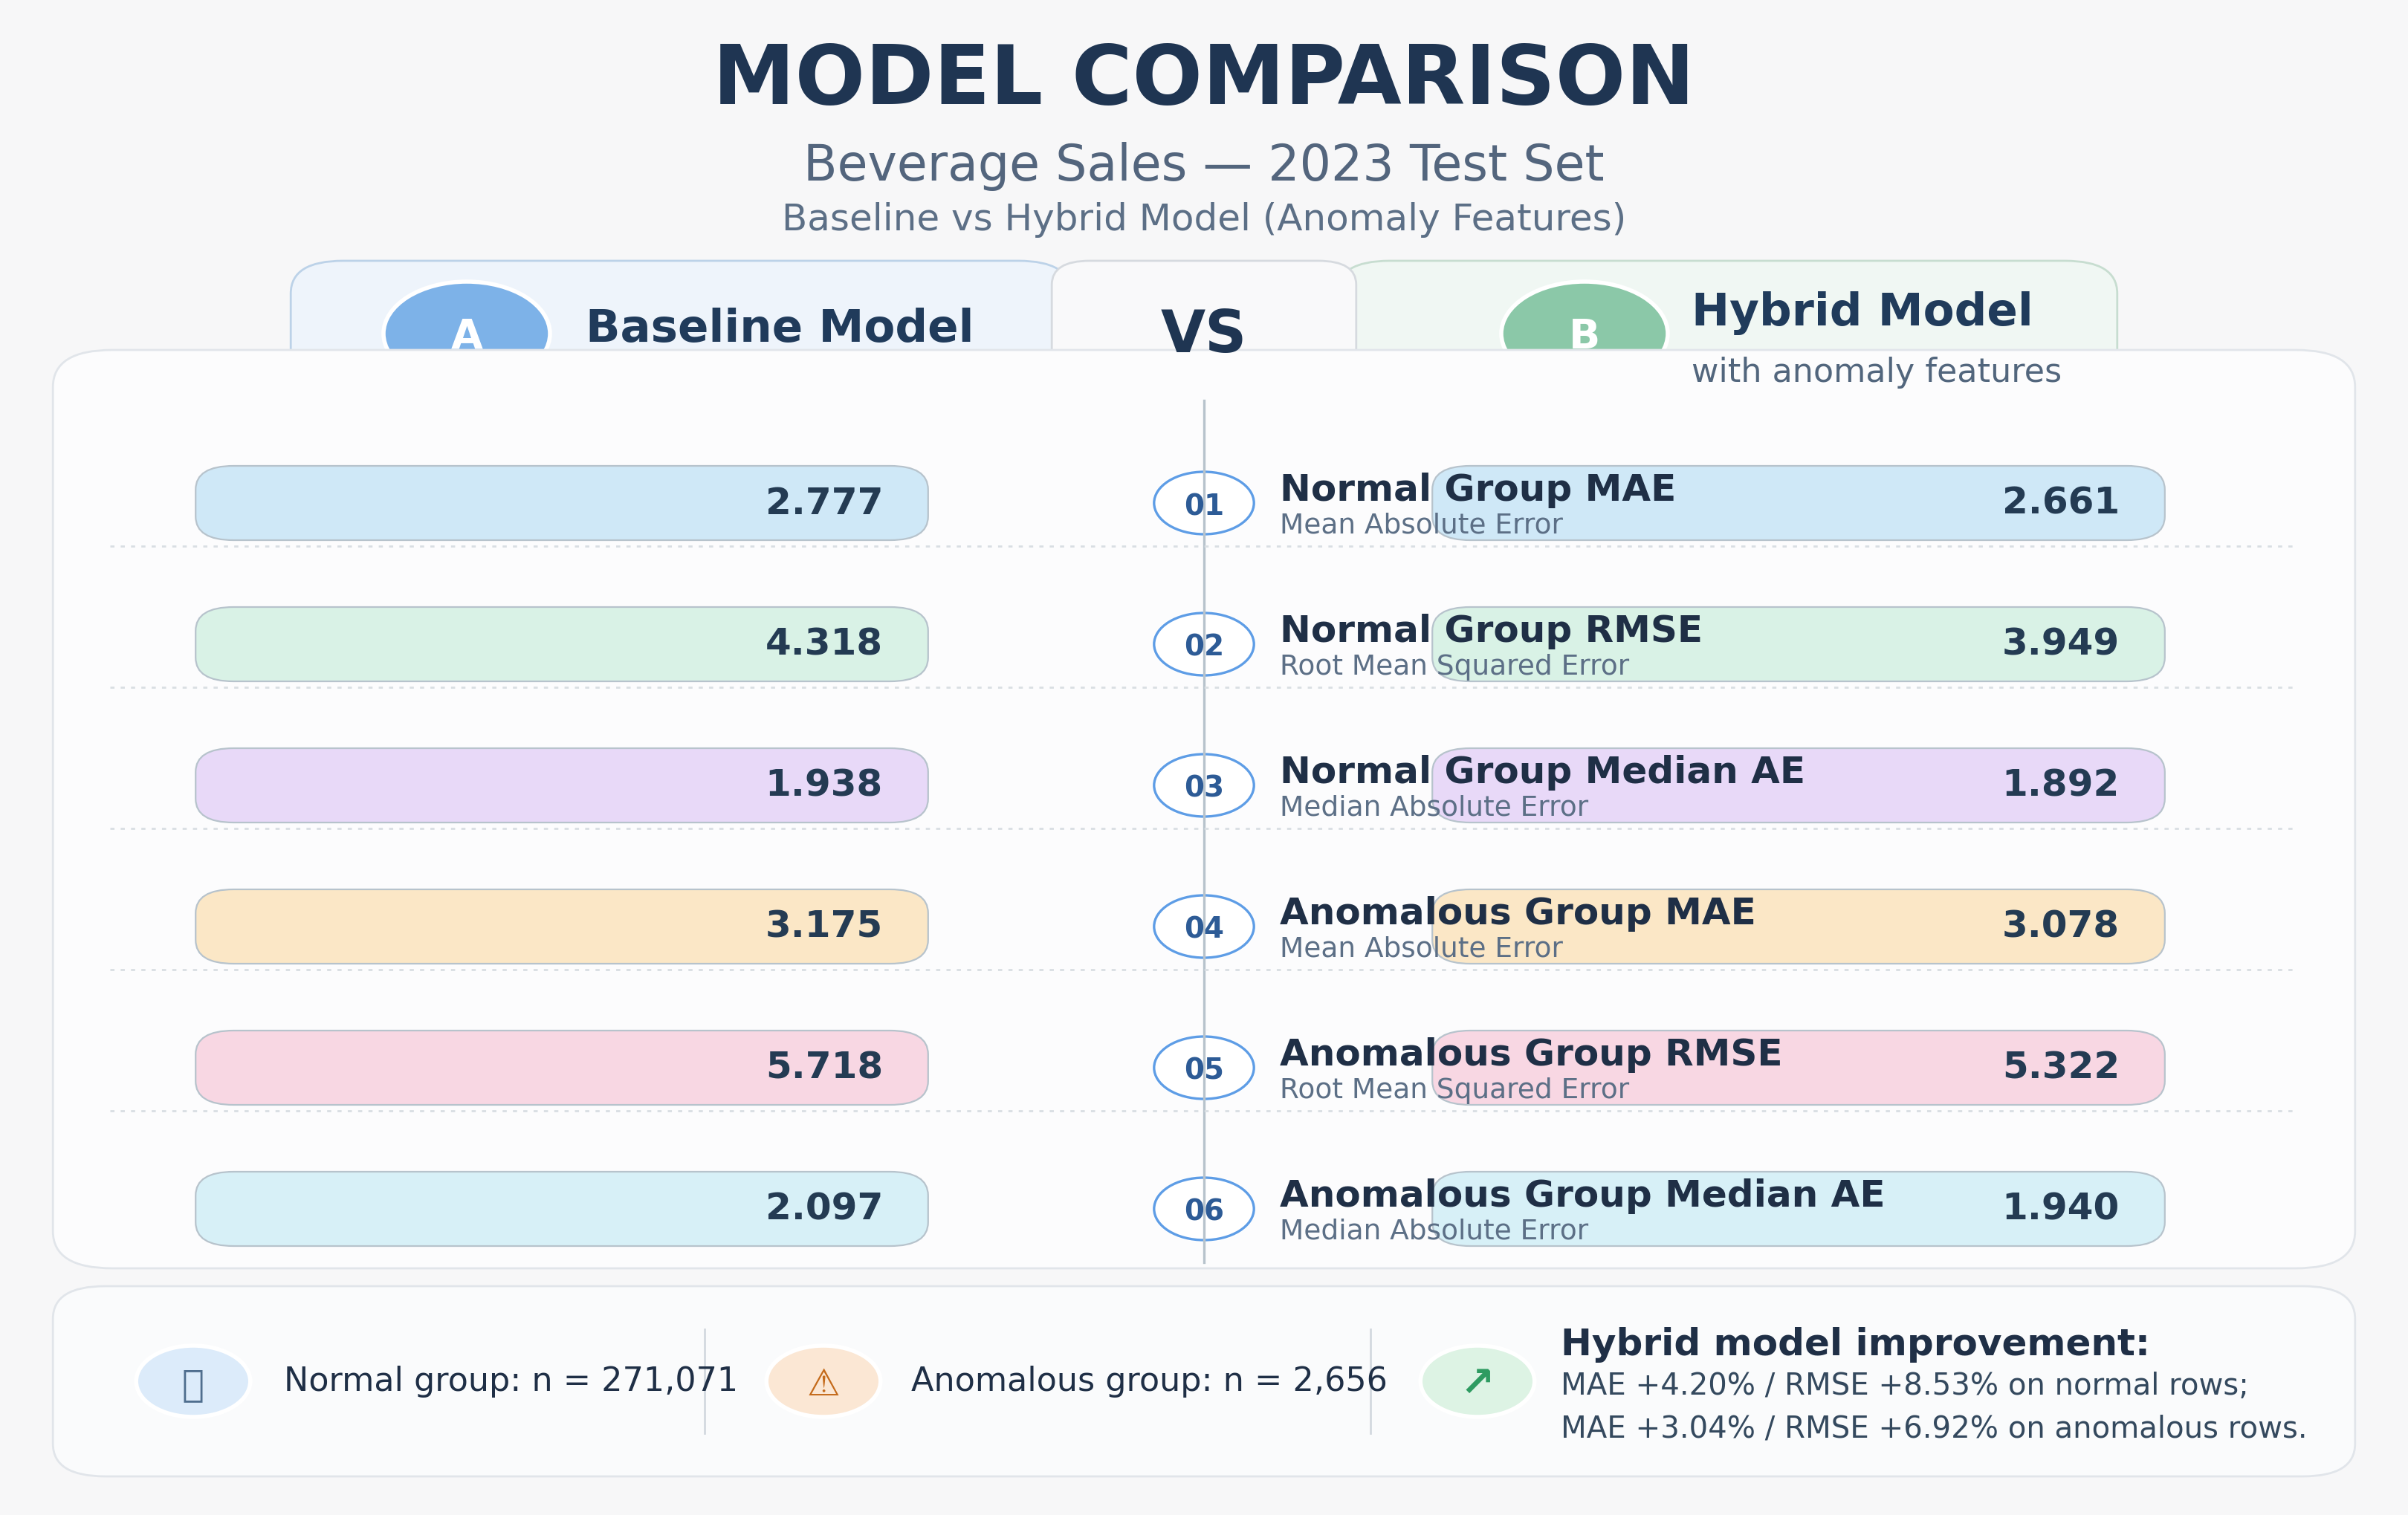

In [48]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle
import numpy as np


def create_model_comparison_infographic(
    output_path="model_comparison_infographic.png",
    dpi=200
):
    # -----------------------------
    # Data
    # -----------------------------
    rows = [
        {"id": "01", "label": "Normal Group MAE",        "sub": "Mean Absolute Error",      "left": 2.777, "right": 2.661, "color": "#CFE8F7"},
        {"id": "02", "label": "Normal Group RMSE",       "sub": "Root Mean Squared Error",  "left": 4.318, "right": 3.949, "color": "#D9F2E6"},
        {"id": "03", "label": "Normal Group Median AE",  "sub": "Median Absolute Error",    "left": 1.938, "right": 1.892, "color": "#E8D9F8"},
        {"id": "04", "label": "Anomalous Group MAE",     "sub": "Mean Absolute Error",      "left": 3.175, "right": 3.078, "color": "#FBE7C6"},
        {"id": "05", "label": "Anomalous Group RMSE",    "sub": "Root Mean Squared Error",  "left": 5.718, "right": 5.322, "color": "#F8D7E3"},
        {"id": "06", "label": "Anomalous Group Median AE","sub": "Median Absolute Error",   "left": 2.097, "right": 1.940, "color": "#D7F0F7"},
    ]

    mae_imp_normal = 4.20
    rmse_imp_normal = 8.53
    mae_imp_anom = 3.04
    rmse_imp_anom = 6.92

    # -----------------------------
    # Figure
    # -----------------------------
    fig = plt.figure(figsize=(16, 10), dpi=dpi)
    ax = plt.axes([0, 0, 1, 1])
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.axis("off")
    fig.patch.set_facecolor("#F7F7F8")
    ax.set_facecolor("#F7F7F8")

    # -----------------------------
    # Helpers
    # -----------------------------
    def rounded_box(x, y, w, h, fc, ec="#D0D5DA", lw=1.0, radius=2.5, alpha=1.0):
        box = FancyBboxPatch(
            (x, y), w, h,
            boxstyle=f"round,pad=0.4,rounding_size={radius}",
            linewidth=lw, edgecolor=ec, facecolor=fc, alpha=alpha
        )
        ax.add_patch(box)
        return box

    def draw_badge(cx, cy, r, color, text, txt_color="white", fs=18):
        circ = Circle((cx, cy), r, facecolor=color, edgecolor="white", linewidth=2)
        ax.add_patch(circ)
        ax.text(cx, cy-0.2, text, ha="center", va="center",
                fontsize=fs, color=txt_color, fontweight="bold")

    def add_text(x, y, s, fs=12, color="#243B53", weight="normal", ha="left", va="center"):
        ax.text(x, y, s, fontsize=fs, color=color, fontweight=weight,
                ha=ha, va=va, family="DejaVu Sans")

    def metric_bar(x, y, w, h, color, value, align="left"):
        rounded_box(x, y, w, h, fc=color, ec="#B7C3CC", lw=0.8, radius=1.6)
        if align == "left":
            add_text(x + w - 1.5, y + h / 2, f"{value:.3f}", fs=18, weight="bold", ha="right")
        else:
            add_text(x + w - 1.5, y + h / 2, f"{value:.3f}", fs=18, weight="bold", ha="right")

    # -----------------------------
    # Title
    # -----------------------------
    add_text(50, 95.5, "MODEL COMPARISON", fs=40, weight="bold", ha="center", color="#1F3552")
    add_text(50, 89.8, "Beverage Sales — 2023 Test Set", fs=24, ha="center", color="#53657D")
    add_text(50, 86.2, "Baseline vs Hybrid Model (Anomaly Features)", fs=18, ha="center", color="#5C6F86")

    # -----------------------------
    # Header panels
    # -----------------------------
    rounded_box(12, 74, 32, 9, fc="#EEF4FB", ec="#BCD2E8", radius=2.2)
    rounded_box(56, 74, 32, 9, fc="#F0F7F3", ec="#C7DDD0", radius=2.2)
    rounded_box(44, 74, 12, 9, fc="#F9F9FA", ec="#D6DADF", radius=1.6)

    draw_badge(19, 78.5, 3.5, "#7DB2E8", "A", fs=20)
    add_text(24, 78.8, "Baseline Model", fs=22, weight="bold", color="#203B5B")

    add_text(50, 78.4, "VS", fs=28, weight="bold", ha="center", color="#1F3552")

    draw_badge(66, 78.5, 3.5, "#8BC8A8", "B", fs=20)
    add_text(70.5, 79.9, "Hybrid Model", fs=22, weight="bold", color="#203B5B")
    add_text(70.5, 75.9, "with anomaly features", fs=16, color="#52667D")

    # -----------------------------
    # Main card
    # -----------------------------
    rounded_box(2, 16, 96, 61, fc="#FCFCFD", ec="#E1E5EA", radius=2.5)

    # Center spine
    ax.plot([50, 50], [16, 74], color="#B7C3CC", linewidth=1.2)

    # Layout coords
    left_x = 8
    left_w = 30
    center_x = 50
    right_x = 60
    right_w = 30
    row_h = 7.5
    row_gap = 2.0
    start_y = 65

    # -----------------------------
    # Rows
    # -----------------------------
    for i, row in enumerate(rows):
        y = start_y - i * (row_h + row_gap)

        if i > 0:
            ax.plot([4, 96], [y + row_h + 1.2, y + row_h + 1.2],
                    color="#D9DEE3", linewidth=1, linestyle=(0, (2, 3)))

        metric_bar(left_x, y, left_w, 4.2, row["color"], row["left"], align="left")
        metric_bar(right_x, y, right_w, 4.2, row["color"], row["right"], align="right")

        draw_badge(center_x, y + 2.1, 2.1, "#FFFFFF", row["id"], txt_color="#2D5B96", fs=14)
        ax.add_patch(Circle((center_x, y + 2.1), 2.1, fill=False, edgecolor="#5E9DE6", linewidth=1.2))

        add_text(53.2, y + 3.0, row["label"], fs=18, weight="bold", color="#1F2F46")
        add_text(53.2, y + 0.6, row["sub"], fs=13.5, color="#5C6F86")

    # -----------------------------
    # Footer
    # -----------------------------
    rounded_box(2, 2, 96, 12, fc="#FAFBFC", ec="#E1E5EA", radius=2.2)

    ax.plot([29, 29], [4.5, 11.5], color="#D3D9DF", linewidth=1)
    ax.plot([57, 57], [4.5, 11.5], color="#D3D9DF", linewidth=1)

    draw_badge(7.5, 8, 2.4, "#DCEBFA", "👥", txt_color="#4F6E8E", fs=18)
    add_text(11.3, 8, "Normal group: n = 271,071", fs=16, color="#1F2F46")

    draw_badge(34, 8, 2.4, "#FBE7D4", "⚠", txt_color="#C46A1A", fs=18)
    add_text(37.7, 8, "Anomalous group: n = 2,656", fs=16, color="#1F2F46")

    draw_badge(61.5, 8, 2.4, "#DDF3E4", "↗", txt_color="#2E9B61", fs=20)
    add_text(65.0, 10.5, "Hybrid model improvement:", fs=18, weight="bold", color="#1F2F46")
    add_text(65.0, 7.7,
             f"MAE +{mae_imp_normal:.2f}% / RMSE +{rmse_imp_normal:.2f}% on normal rows;",
             fs=14.5, color="#34495E")
    add_text(65.0, 4.8,
             f"MAE +{mae_imp_anom:.2f}% / RMSE +{rmse_imp_anom:.2f}% on anomalous rows.",
             fs=14.5, color="#34495E")

    plt.savefig(output_path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


# Example
create_model_comparison_infographic("model_comparison_infographic.png")